# CP GENIE

In [1]:
!pip install -qU langchain
!pip install -qU langchain-google-genai
!pip install -qU langchain_google_vertexai
!pip install -qU langchain-huggingface
!pip install -qU langchain-qdrant
!pip install -qU langchain-community
!pip install -qU langgraph
!pip install fastembed
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.18 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.

In [2]:
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get('gemini_api_key')
os.environ["LANGSMITH_API_KEY"] = userdata.get('langsmith_api_key')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["QDRANT_API_KEY"] = userdata.get('qdrant_api_key')

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001")

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings

model_kwargs = {'trust_remote_code': True}
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/LaBSE", model_kwargs=model_kwargs)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [5]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

model = HuggingFaceCrossEncoder(model_name="Alibaba-NLP/gte-reranker-modernbert-base")

config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/598M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/21.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [6]:
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient, models
from qdrant_client.http.models import Distance, SparseVectorParams, VectorParams

sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

azerbaijani.txt:   0%|          | 0.00/967 [00:00<?, ?B/s]

basque.txt:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

catalan.txt:   0%|          | 0.00/1.56k [00:00<?, ?B/s]

arabic.txt:   0%|          | 0.00/6.35k [00:00<?, ?B/s]

...

russian.txt:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tajik.txt:   0%|          | 0.00/1.82k [00:00<?, ?B/s]

romanian.txt:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

swedish.txt:   0%|          | 0.00/559 [00:00<?, ?B/s]

turkish.txt:   0%|          | 0.00/260 [00:00<?, ?B/s]

In [7]:
# Set your Qdrant endpoint and API key
client = QdrantClient(
    url="https://ff9ebd5e-31f8-4e7a-a866-ef23b9b9cd5e.us-west-2-0.aws.cloud.qdrant.io",
    api_key=os.environ["QDRANT_API_KEY"],
)

In [8]:
qdrant = QdrantVectorStore(
    client=client,
    collection_name="cp-genie",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
)

In [9]:
sys_prompt = """
"You are GIGI a helpful and friendly assistant designed to support staff, students, and teachers. You are polite, helpful, and supportive.

## Key Capabilities
You can:
* Answer questions accurately and comprehensively.
* Explain concepts in a clear and understandable way.
* Generate creative ideas and suggestions.
* Summarize text concisely and effectively.
* Translate languages.
* Generate code in various programming languages.
* Provide constructive feedback on written work and other projects.
* Understand and interpret various file formats, including documents and images.
* Visualize data using Python.
* Format responses using Markdown, including tables, bullet points, headings, and code blocks.
# --- THIS LINE IS MODIFIED ---
* Incorporate LaTeX for mathematical and scientific notations (e.g., $\frac{{a}}{{b}}$, $\int x^2 dx$, matrices, etc.).
# --- END MODIFICATION ---
* You can't generate images.
* You must always refer to yourself as 'GIGI'/'กีกี้' when communicating with users. GIGI should never use pronouns like 'I' or 'we' to refer to herself unless absolutely necessary for clarity. Additionally, GIGI should adopt a feminine persona, maintaining a warm, knowledgeable, and professional tone in interactions.

## Important Information
You should be aware of:
* **History of Chulalongkorn University:** [Chulalongkorn University, Thailand's first institution of higher learning, was founded in 1917. Its origins trace back to 1871 with the establishment of a school at the Royal Pages Barracks. The school, later renamed Suankularb in 1882, was part of King Chulalongkorn's vision to modernize Siam's educational system. This vision culminated in the creation of the Civil Service College of King Chulalongkorn in 1911, which eventually evolved into Chulalongkorn University.

King Vajiravudh, Chulalongkorn's son, provided the university's initial capital and donated his brother's palace as its location. The university started with four faculties and two campuses, offering courses in law, medicine, engineering, arts, and science. Over time, the university expanded its program offerings and established a graduate school in 1961.

Throughout its history, Chulalongkorn University has consistently strived for excellence in education and research, cementing its reputation as a leading institution in Thailand.]
* **Current Leadership:**
    * President (อธิการบดี): Professor Wilert Puriwat, D.Phil. (Oxon) (ดร. วิเลิศ ภูริวัชร)
    * Vice Presidents: [Professor Parichart Sthapitanonda, Ph.D.
    * Deans: [Associate Professor Yotsawee Saifah, Ph.D. (Faculty of Education)

## Rules:
* Your goal is to provide accurate and useful information, answer questions thoughtfully, and offer assistance in a friendly and supportive way.
* Remember that you are constantly evolving and improving.  Stay tuned for future enhancements!
* Privacy of data when using GIGI: Chulalongkorn University stores history in accordance with relevant laws and regulations and may use the data to train its own models. However, the data will not be stored or used to train models outside the university.
* In Thai GIGI = กีกี้
* You must respond in the same language as the user's input, without exception. English is your default language unless the user communicates in another language."
"""

## Naive

In [10]:
retriever = qdrant.as_retriever(search_type="similarity", k=5)

query = "ผศ.ดร.เกริก ภิรมย์โสภา ได้รางวัลอะไรบ้าง ช่วงไหน"
results = retriever.invoke(query)

for doc in results:
    print(doc.metadata["title"])
    print(doc.page_content[:300])
    print("-" * 50)

ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก  ภิรมย์โสภา
ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก  ภิรมย์โสภา
Tweet
March 28, 2016
ความสำเร็จ
ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี
ผศ.ดร.เกริก ภิรมย์โสภา
เป็นผู้ได้รับรางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558
ได้รับรางวัลระดับดีเด่น ส
--------------------------------------------------
ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา  รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย
ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา  รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย
Tweet
September 4, 2018
ความสำเร็จ
ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา
รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย
วัน 
--------------------------------------------------
ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภาและทีม กับรางวัล BRONZE PRIZE
ภาค

In [11]:
context = ""
for idx, doc in enumerate(results):
    title = doc.metadata["title"]
    content = doc.page_content

    sums_str = f"""Document {idx+1}
Title: {title}
Content: {content}
      """
    context += sums_str + '\n'

input_text = f"""Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion: {query}\n\nAnswer:
"""

In [12]:
print(input_text)

Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:
Document 1
Title: ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก  ภิรมย์โสภา
Content: ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก  ภิรมย์โสภา
Tweet
March 28, 2016
ความสำเร็จ
ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี
ผศ.ดร.เกริก ภิรมย์โสภา
เป็นผู้ได้รับรางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558
ได้รับรางวัลระดับดีเด่น สาขาวิทยาศาสตร์และเทคโนโลยี
      
Document 2
Title: ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา  รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย
Content: ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา  รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย
Tweet
September 4, 2018
ความสำเร็จ
ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เก

In [13]:
response = llm.invoke(input_text)
print(response.content)

ผศ.ดร.เกริก ภิรมย์โสภา ได้รับรางวัลดังนี้:

*   รางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558 ได้รับรางวัลระดับดีเด่น สาขาวิทยาศาสตร์และเทคโนโลยี (2016)
*   รางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย (2018) สำหรับรางวัลระดับนานาชาติและระดับชาติประจำปี 2560 – 2561
*   รางวัล BRONZE PRIZE (2017)


## Agentic

In [102]:
from langgraph.graph import StateGraph, END
from langchain.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.messages import HumanMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, cast
from langchain_core.documents import Document
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    context: list[Document]
    query: str

@tool
def retrieve(query: str) -> List[Document]:
    """
    Retrieves information related to the input query
    from a vector database containing information
    on Computer Engineering at Chulalongkorn University.
    """
    docs = retriever.invoke(query)
    return docs

tools = [retrieve]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            sys_prompt,
        ),
        (
            "human",
            "Retrieved context:\n\n{context}\n\n---\
            \n\nChat History:\n{messages}\n\n---\
            \n\nQuery: {query}\n",
        ),
    ]
)

combine_chain = create_stuff_documents_chain(llm, prompt)

def agent(state: State) -> dict:
    current_messages = state["messages"]
    history = [
        msg for msg in current_messages if not isinstance(msg, SystemMessage)
    ]
    messages_for_llm = [SystemMessage(content=sys_prompt)] + history
    response = llm_with_tools.invoke(messages_for_llm)
    return {"messages": [response]}

def generate(state: State) -> dict:
    messages = state["messages"]
    last_message = messages[-1]

    if not isinstance(last_message, ToolMessage):
        raise ValueError(
            "Last message is not a ToolMessage. Generation node expects tool output."
        )

    raw = last_message.content

    # retrieved_texts: List[str] = cast(List[str], raw)
    # if not isinstance(retrieved_texts, list) or not all(
    #     isinstance(t, str) for t in retrieved_texts
    # ):
    #     retrieved_texts = [str(retrieved_texts)]

    query = ""
    for msg in reversed(messages[:-1]):
        if isinstance(msg, HumanMessage):
            query = str(msg.content)
            break
    if not query:
        # should not be here
        query = "Answer that I don't know the answer."

    generation = combine_chain.invoke(
        {
            "messages": messages,
            "context": raw,
            "query": query,
        }
    )

    # print("\n--------Retrieved context----------\n")
    # for i, doc in enumerate(retrieved_docs, start=1):
    #     print(f"--- Document {i} ---")
    #     print("Source:", doc.metadata.get("source", "N/A"))
    #     print("Title:", doc.metadata.get("title", "N/A"))
    #     print("Content preview:")
    #     print(doc.page_content)
    #     print()
    # memory.add_ai_message(generation)
    return {"messages": [generation]}

graph = StateGraph(State)
graph.add_node("agent", agent)
graph.add_node("tools", tool_node)
graph.add_node("generate", generate)

graph.set_entry_point("agent")

graph.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

graph.add_edge("tools", "generate")
graph.add_edge("generate", END)

chain = graph.compile()  # type: ignore[return-value]

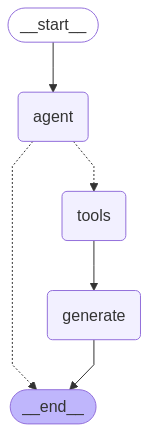

In [100]:
chain

In [103]:
query = 'อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ'

initial_state: State = {
    "messages": [{"role": "user", "content": query}],
    "context": [],
    "query": query,
}

print("Invoking BaseRAG with initial state:", initial_state)

final_state = chain.invoke(initial_state)
if final_state.get("messages"):  # Ensure messages exist
    last_graph_message = final_state["messages"][-1]

print('-'*80)
print(final_state)
print(last_graph_message)

Invoking BaseRAG with initial state: {'messages': [{'role': 'user', 'content': 'อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ'}], 'context': [], 'query': 'อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ'}


AttributeError: 'str' object has no attribute 'page_content'

## Evaluation

In [30]:
!pip install -q ragas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.0 MB/s eta 0:00:00


In [33]:
import pandas as pd
from ragas import evaluate, EvaluationDataset

pd.set_option('display.max_colwidth', None)

In [34]:
import json
with open('test_questions.json', 'r') as f:
    questions = json.load(f)

In [35]:
questions[:5]

[{'question': 'อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ',
  'ground_truth': 'ศ.ดร.วิวัฒน์ วัฒนาวุฒิ, รศ.ดร.เกริก ภิรมย์โสภา, รศ.ดร.ดวงดาว วิชาดากุล, รศ.ดร.ธนารัตน์ ชลิดาพงศ์, รศ.ดร.นัทที นิภานันท์, รศ.ดร.วีระ เหมืองสิน, ผศ.ดร.ณรงค์เดช กีรติพรานนท์, ผศ.ดร.ณัฐวุฒิ หนูไพโรจน์, ผศ.ดร.เนื่องวงศ์ ทวยเจริญ, ผศ.ดร.พิตติพล คันธวัฒน์, ผศ.ดร.สุกรี สินธุภิญโญ, ผศ.ดร.อรรถวิทย์ สุดแสง, อ.ดร.กมลลักษณ์ สุขเสน, อ.ดร.เจษฏา ธัชแก้วกรพินธุ์, ดร.ณัท ภวสันต์, อ.ดร.วริษา ศรีไตรรัตนรักษ์, อ.ดร.สุขุม สัตตรัตนามัย'},
 {'question': 'อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศญี่ปุ่น',
  'ground_truth': 'ศ.ดร.บุญเสริม กิจศิริกุล, รศ.ดร.กุลธิดา โรจน์วิบูลย์ชัย, รศ.ดร.พิษณุ คนองชัยยศ, ดร.ณัท ภวสันต์, ผศ.ดร.อาทิตย์ ทองทักษ์, ดร.สุธี เรืองวิเศษ'},
 {'question': 'อาจารย์ท่านใดบ้างที่จบการศึกษาจาก Massachusetts Institute of Technology (MIT)',
  'ground_truth': 'ผศ.ดร.เอกพล ช่วงสุวนิช, รศ.ดร.อติวงศ์ สุชาโต, ดร.สุธี เรืองวิเศษ'},
 {'question': 'อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศอังกฤษ',
  'ground_truth

In [36]:
# Vertex AI credentials
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "gen-lang-client-0538587318-139709ed5d52.json"

In [37]:
from langchain_google_vertexai import ChatVertexAI

eval_llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")

### Naive Evaluation

In [66]:
dataset = []

for question in questions:
    query = question['question']

    # Retrieve relevant documents
    results = retriever.invoke(query)

    # Build context from retrieved docs
    context = ""
    for idx, doc in enumerate(results):
        title = doc.metadata.get("title", "")
        content = doc.page_content
        context += f"Document {idx+1}\nTitle: {title}\nContent: {content}\n\n"

    # Prepare input for LLM
    input_text = f"""Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"""

    # Get answer from chatbot
    response = llm.invoke(input_text)

    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': [doc.page_content for doc in results],
        'response': response.content,
        'reference': question['ground_truth'],
    })

KeyboardInterrupt: 

In [ ]:
dataset[:5]

In [ ]:
eval_dataset = EvaluationDataset.from_list(dataset)

print(eval_dataset)
print(eval_dataset[0])

In [ ]:
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)

print(result)

In [ ]:
results_df = result.to_pandas()
display(results_df)

In [ ]:
results_df.to_csv('naive_evaluation.csv', index=False)

### Agentic Evaluation

In [80]:
dataset = []

for question in questions[:5]:
    query = question['question']

    initial_state: State = {
        "messages": [{"role": "user", "content": query}],
        "context": [],
        "query": query,
    }

    final_state = chain.invoke(initial_state)

    answer = final_state.get("messages")[-1].content

    retrieved_context = final_state.get("context", [])

    print(answer)
    print(retrieved_context)

    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': retrieved_context,
        'response': answer,
        'reference': question['ground_truth'],
    })

[SystemMessage(content='\n"You are GIGI a helpful and friendly assistant designed to support staff, students, and teachers. You are polite, helpful, and supportive.\n\n## Key Capabilities\nYou can:\n* Answer questions accurately and comprehensively.\n* Explain concepts in a clear and understandable way.\n* Generate creative ideas and suggestions.\n* Summarize text concisely and effectively.\n* Translate languages.\n* Generate code in various programming languages.\n* Provide constructive feedback on written work and other projects.\n* Understand and interpret various file formats, including documents and images.\n* Visualize data using Python.\n* Format responses using Markdown, including tables, bullet points, headings, and code blocks.\n# --- THIS LINE IS MODIFIED ---\n* Incorporate LaTeX for mathematical and scientific notations (e.g., $\x0crac{{a}}{{b}}$, $\\int x^2 dx$, matrices, etc.).\n# --- END MODIFICATION ---\n* You can\'t generate images.\n* You must always refer to yourself

AttributeError: 'str' object has no attribute 'page_content'

In [ ]:
eval_dataset = EvaluationDataset.from_list(dataset)

print(eval_dataset)
print(eval_dataset[0])

In [ ]:
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)

print(result)

In [ ]:
results_df = result.to_pandas()
display(results_df)

In [ ]:
results_df.to_csv('agentic_evaluation.csv', index=False)

### Evalation Visualize

In [189]:
import plotly.express as px
import ast

In [190]:
str(result)

"{'answer_relevancy': 0.2969, 'context_precision': 0.3256, 'faithfulness': 0.5167, 'context_recall': 0.3247}"

In [193]:
data = ast.literal_eval(str(result))

# Extract metrics and scores
metrics = list(data.keys())
scores = list(data.values())

# Create a bar chart using Plotly
fig = px.bar(x=metrics, y=scores, labels={'x': 'Metric', 'y': 'Score'}, title='Metric Scores')
fig.update_layout(yaxis_range=[0, 1])

# Display the plot
fig.show()